In [ ]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
import seaborn as sns



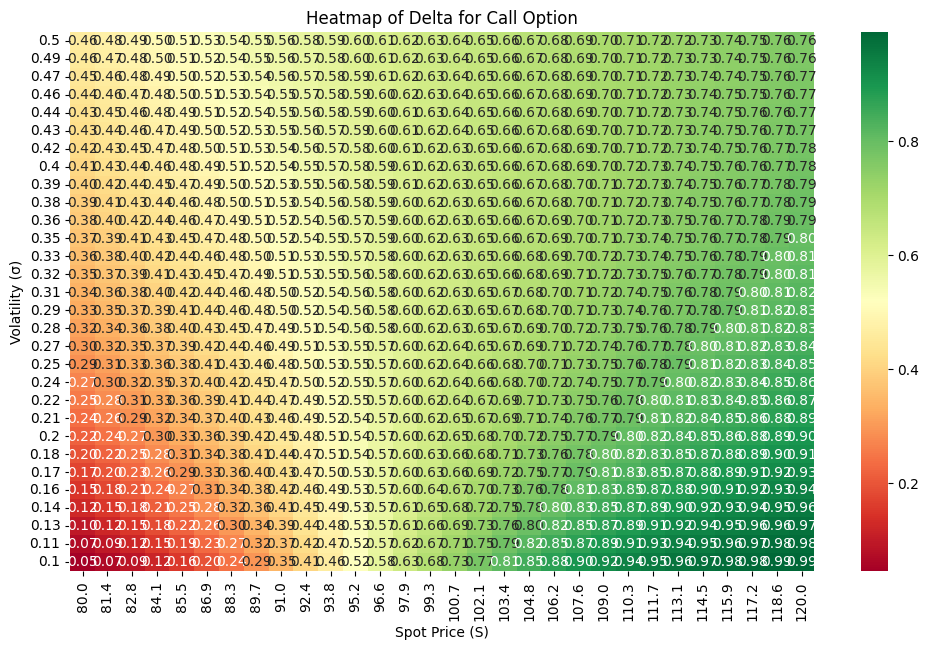

In [ ]:
def bsm_price_and_greeks(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
        delta = si.norm.cdf(d1)
    else:
        price = K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)
        delta = -si.norm.cdf(-d1)

    gamma = si.norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta = (-S * si.norm.pdf(d1) * sigma / (2 * np.sqrt(T))
             - r * K * np.exp(-r * T) * si.norm.cdf(d2 if option_type == 'call' else -d2))
    vega = S * si.norm.pdf(d1) * np.sqrt(T)
    rho = K * T * np.exp(-r * T) * si.norm.cdf(d2 if option_type == 'call' else -d2)

    return price, delta, gamma, theta, vega, rho

# Parameters
K = 100        # Strike price
T = 1          # Time to maturity (years)
r = 0.05       # Risk-free rate
option_type = 'call'  # 'call' or 'put'

# Grid ranges for visualization
spot_min, spot_max, spot_steps = 80, 120, 30
vol_min, vol_max, vol_steps = 0.1, 0.5, 30

spot_range = np.linspace(spot_min, spot_max, spot_steps)
vol_range = np.linspace(vol_min, vol_max, vol_steps)

# Choose Greek or price to plot
greek_to_plot = 'Delta'  # Options: Price, Delta, Gamma, Theta, Vega, Rho

heatmap_data = np.zeros((vol_steps, spot_steps))

for i, sigma in enumerate(vol_range):
    for j, S in enumerate(spot_range):
        price, delta, gamma, theta, vega, rho = bsm_price_and_greeks(S, K, T, r, sigma, option_type)
        values = {
            "Price": price,
            "Delta": delta,
            "Gamma": gamma,
            "Theta": theta,
            "Vega": vega,
            "Rho": rho
        }
        heatmap_data[i, j] = values[greek_to_plot]

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_data,
    xticklabels=np.round(spot_range, 1),
    yticklabels=np.round(vol_range, 2),
    cmap="RdYlGn",
    annot=True,
    fmt=".2f"
)
plt.xlabel("Spot Price (S)")
plt.ylabel("Volatility (σ)")
plt.title(f"Heatmap of {greek_to_plot} for {option_type.capitalize()} Option")
plt.gca().invert_yaxis()  # Make volatility increase bottom to top
plt.show()
